Natural Language Inferencing (NLI) is a classic NLP (Natural Language Processing) problem that involves taking two sentences (the _premise_ and the _hypothesis_ ), and deciding how they are related- if the premise entails the hypothesis, contradicts it, or neither.

In this tutorial we'll look at the _Contradictory, My Dear Watson_ competition dataset, build a preliminary model using PyTorch, Hugging Face Transformers, and BERT, and prepare a submission file.

This is a local, PyTorch-based adaptation of the original Kaggle TensorFlow/Keras tutorial notebook.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Local run: data files live in the same directory as this notebook
import os
for filename in os.listdir('.'):
    if filename.endswith('.csv'):
        print(filename)

sample_submission.csv
submission.csv
test.csv
train.csv


In [2]:
import truststore
truststore.inject_into_ssl()  # trust the OS cert store (fixes HF Hub downloads behind the corporate proxy)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

C:\Users\alher\Desktop\Watson\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's set up our device (GPU if available, otherwise CPU).

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


The training set contains a premise, a hypothesis, a label (0 = entailment, 1 = neutral, 2 = contradiction), and the language of the text. For more information about what these mean and how the data is structured, check out the data page: https://www.kaggle.com/c/contradictory-my-dear-watson/data

In [4]:
train = pd.read_csv("train.csv")

In [5]:
train.head()

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


Let's look at one of the pairs of sentences.

In [6]:
train.premise.values[1]

'These are issues that we wrestle with in practice groups of law firms, she said. '

In [7]:
train.hypothesis.values[1]

'Practice groups are not permitted to work on these issues.'

In [8]:
train.label.values[1]

2

These statements are contradictory, and the label shows that.

Let's look at the distribution of languages in the training set.

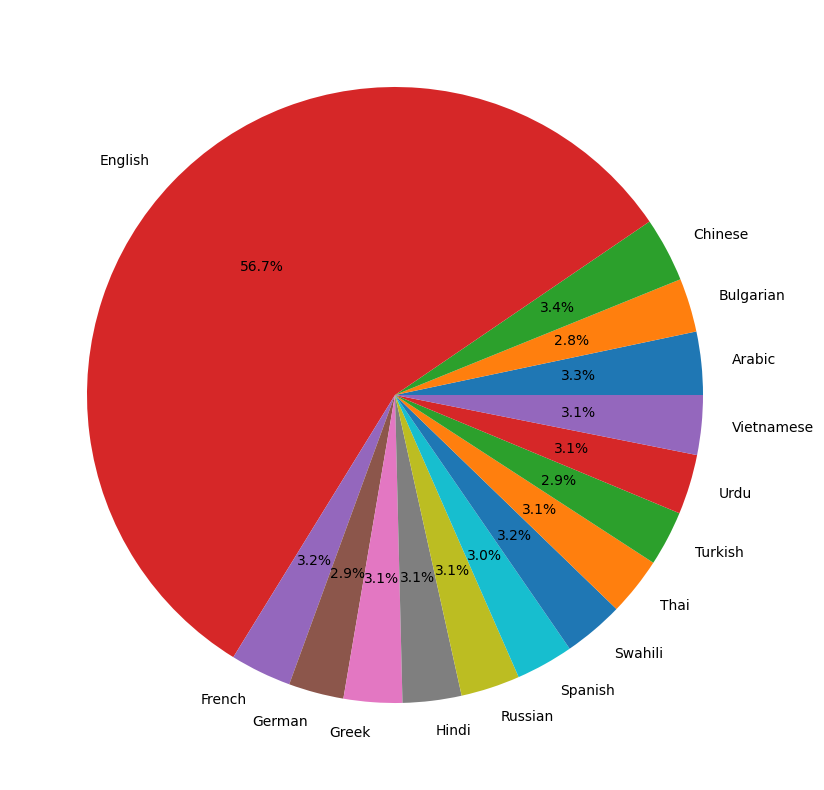

In [9]:
labels, frequencies = np.unique(train.language.values, return_counts = True)

plt.figure(figsize = (10,10))
plt.pie(frequencies,labels = labels, autopct = '%1.1f%%')
plt.show()

## Preparing Data for Input

To start out, we can use a pretrained model. Here, we'll use a multilingual BERT model from huggingface. For more information about BERT, see: https://github.com/google-research/bert/blob/master/multilingual.md

First, we download the tokenizer.

In [10]:
model_name = 'bert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

Tokenizers turn sequences of words into arrays of numbers. Let's look at an example:

In [11]:
def encode_sentence(s):
    return tokenizer.encode(s, add_special_tokens=False) + [tokenizer.sep_token_id]

In [12]:
encode_sentence("I love machine learning")

[146, 16138, 21432, 26901, 102]

BERT uses three kind of input data- input word IDs, input masks, and input type IDs.

These allow the model to know that the premise and hypothesis are distinct sentences, and also to ignore any padding from the tokenizer.

We add a [CLS] token to denote the beginning of the inputs, and a [SEP] token to denote the separation between the premise and the hypothesis. We also need to pad all of the inputs to be the same size. For more information about BERT inputs, see: https://huggingface.co/transformers/model_doc/bert.html#bertmodel

Now, we're going to encode all of our premise/hypothesis pairs for input into BERT.

In [13]:
max_len = 50

def bert_encode(premises, hypotheses, tokenizer, max_len=max_len):
    encodings = tokenizer(
        list(premises), list(hypotheses),
        padding='max_length', truncation=True, max_length=max_len,
        return_tensors='pt')
    return {
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'token_type_ids': encodings['token_type_ids'],
    }

In [14]:
train_input = bert_encode(train.premise.values, train.hypothesis.values, tokenizer)

In [15]:
from sklearn.model_selection import train_test_split

class NLIDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['label'] = self.labels[idx]
        return item

labels = torch.tensor(train.label.values, dtype=torch.long)
train_idx, val_idx = train_test_split(
    np.arange(len(labels)), test_size=0.2, random_state=42)

train_encodings = {k: v[train_idx] for k, v in train_input.items()}
val_encodings = {k: v[val_idx] for k, v in train_input.items()}

train_dataset = NLIDataset(train_encodings, labels[train_idx])
val_dataset = NLIDataset(val_encodings, labels[val_idx])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

## Creating & Training Model

Now, we can incorporate the BERT transformer into a PyTorch model. This model was inspired by the model in this notebook: https://www.kaggle.com/tanulsingh077/deep-learning-for-nlp-zero-to-transformers-bert#BERT-and-Its-Implementation-on-this-Competition, which is a wonderful introduction to NLP!

In [16]:
class NLIModel(nn.Module):
    def __init__(self, model_name, num_labels=3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

In [17]:
model = NLIModel(model_name).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {num_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 47662.55it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters: 177,855,747


In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

epochs = 2

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    baseline_val_accuracy = val_correct / val_total
    print(f'Epoch {epoch+1}/{epochs} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {val_loss/val_total:.4f} - val_accuracy: {baseline_val_accuracy:.4f}')

Epoch 1/2 - loss: 0.9751 - accuracy: 0.5103 - val_loss: 0.8691 - val_accuracy: 0.5969


Epoch 2/2 - loss: 0.7691 - accuracy: 0.6639 - val_loss: 0.8124 - val_accuracy: 0.6353


In [19]:
test = pd.read_csv("test.csv")
test_input = bert_encode(test.premise.values, test.hypothesis.values, tokenizer)

In [20]:
test.head()

,id,premise,hypothesis,lang_abv,language
0,c6d58c3f69,بکس، کیسی، راہیل، یسعیاہ، کیلی، کیلی، اور کولم...,"کیسی کے لئے کوئی یادگار نہیں ہوگا, کولمین ہائی...",ur,Urdu
1,cefcc82292,هذا هو ما تم نصحنا به.,عندما يتم إخبارهم بما يجب عليهم فعله ، فشلت ال...,ar,Arabic
2,e98005252c,et cela est en grande partie dû au fait que le...,Les mères se droguent.,fr,French
3,58518c10ba,与城市及其他公民及社区组织代表就IMA的艺术发展进行对话&amp,IMA与其他组织合作，因为它们都依靠共享资金。,zh,Chinese
4,c32b0d16df,Она все еще была там.,"Мы думали, что она ушла, однако, она осталась.",ru,Russian


## Generating & Submitting Predictions

In [21]:
model.eval()
predictions = []
with torch.no_grad():
    for i in range(0, len(test), batch_size):
        input_ids = test_input['input_ids'][i:i+batch_size].to(device)
        attention_mask = test_input['attention_mask'][i:i+batch_size].to(device)
        token_type_ids = test_input['token_type_ids'][i:i+batch_size].to(device)
        logits = model(input_ids, attention_mask, token_type_ids)
        predictions.extend(logits.argmax(dim=-1).cpu().tolist())

The submission file will consist of the ID column and a prediction column. We can just copy the ID column from the test file, make it a dataframe, and then add our prediction column.

In [22]:
submission = test.id.copy().to_frame()
submission['prediction'] = predictions

In [23]:
submission.head()

,id,prediction
0,c6d58c3f69,2
1,cefcc82292,1
2,e98005252c,0
3,58518c10ba,0
4,c32b0d16df,2


In [24]:
submission.to_csv("submission.csv", index = False)

And now we've created our submission file, which can be submitted to the competition. Good luck!

## Mejora: transfer learning desde un modelo preentrenado en NLI (mDeBERTa)

El baseline de arriba parte de `bert-base-multilingual-cased`, preentrenado solo con masked-LM genérico — no sabe nada de NLI de partida, así que tiene que aprender la tarea entera durante el fine-tuning.

Aquí partimos en cambio de [`MoritzLaurer/mDeBERTa-v3-base-mnli-xnli`](https://huggingface.co/MoritzLaurer/mDeBERTa-v3-base-mnli-xnli), que ya está fine-tuneado en MNLI + XNLI (mismo formato premise/hypothesis/entailment-neutral-contradiction que esta competición, en 100 idiomas). Congelamos las capas inferiores del encoder (features lingüísticas más genéricas, ya bien aprendidas) y solo entrenamos las últimas capas más un classifier head nuevo — transfer learning real en vez de fine-tuning completo desde cero.

In [25]:
model_name_nli = 'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli'
tokenizer_nli = AutoTokenizer.from_pretrained(model_name_nli)
model_nli = NLIModel(model_name_nli).float().to(device)  # el checkpoint se guardo en fp16; el classifier nuevo es fp32

total_params_nli = sum(p.numel() for p in model_nli.parameters())


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 17213.64it/s]


[transformers] DebertaV2Model LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Congelamos embeddings + capas inferiores del encoder; dejamos entrenables solo las últimas `K` capas del encoder y el classifier head nuevo. El naming de las capas de DeBERTa-v3 (`encoder.layer.{i}.*`) se verificó antes de escribir este filtro.

In [26]:
K = 3  # nº de capas superiores del encoder que se entrenan (de 12 en total)

for name, param in model_nli.bert.named_parameters():
    if name.startswith('encoder.layer.'):
        layer_idx = int(name.split('.')[2])
        param.requires_grad = layer_idx >= (model_nli.bert.config.num_hidden_layers - K)
    else:
        param.requires_grad = False

for param in model_nli.classifier.parameters():
    param.requires_grad = True

trainable_params_nli = sum(p.numel() for p in model_nli.parameters() if p.requires_grad)
print(f'Parametros entrenables: {trainable_params_nli:,} de {total_params_nli:,} '
      f'({trainable_params_nli/total_params_nli:.1%})')

Parametros entrenables: 21,265,923 de 278,221,059 (7.6%)


Volvemos a tokenizar premise/hypothesis con el tokenizer de mDeBERTa (vocabulario distinto al de mBERT) reutilizando el mismo split train/val (`train_idx`/`val_idx`) que el baseline, para que la comparación de métricas sea justa.

In [27]:
train_input_nli = bert_encode(train.premise.values, train.hypothesis.values, tokenizer_nli)

train_encodings_nli = {k: v[train_idx] for k, v in train_input_nli.items()}
val_encodings_nli = {k: v[val_idx] for k, v in train_input_nli.items()}

train_dataset_nli = NLIDataset(train_encodings_nli, labels[train_idx])
val_dataset_nli = NLIDataset(val_encodings_nli, labels[val_idx])

train_loader_nli = DataLoader(train_dataset_nli, batch_size=batch_size, shuffle=True)
val_loader_nli = DataLoader(val_dataset_nli, batch_size=batch_size)

Entrenamos solo los parámetros no congelados, con warmup + decaimiento lineal del learning rate y gradient clipping — prácticas estándar de fine-tuning de BERT que no estaban en el baseline.

In [28]:
from transformers import get_linear_schedule_with_warmup

optimizer_nli = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_nli.parameters()), lr=2e-5)

epochs_nli = 2
total_steps_nli = len(train_loader_nli) * epochs_nli
scheduler_nli = get_linear_schedule_with_warmup(
    optimizer_nli,
    num_warmup_steps=int(0.1 * total_steps_nli),
    num_training_steps=total_steps_nli)

for epoch in range(epochs_nli):
    model_nli.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for batch in train_loader_nli:
        optimizer_nli.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        batch_labels = batch['label'].to(device)

        logits = model_nli(input_ids, attention_mask, token_type_ids)
        loss = criterion(logits, batch_labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nli.parameters(), max_norm=1.0)
        optimizer_nli.step()
        scheduler_nli.step()

        train_loss += loss.item() * batch_labels.size(0)
        train_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model_nli.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for batch in val_loader_nli:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            batch_labels = batch['label'].to(device)

            logits = model_nli(input_ids, attention_mask, token_type_ids)
            loss = criterion(logits, batch_labels)

            val_loss += loss.item() * batch_labels.size(0)
            val_correct += (logits.argmax(dim=-1) == batch_labels).sum().item()
            val_total += batch_labels.size(0)

    nli_val_accuracy = val_correct / val_total
    print(f'Epoch {epoch+1}/{epochs_nli} - '
          f'loss: {train_loss/train_total:.4f} - accuracy: {train_correct/train_total:.4f} - '
          f'val_loss: {val_loss/val_total:.4f} - val_accuracy: {nli_val_accuracy:.4f}')

Epoch 1/2 - loss: 0.6424 - accuracy: 0.7166 - val_loss: 0.4855 - val_accuracy: 0.8069


Epoch 2/2 - loss: 0.4691 - accuracy: 0.8145 - val_loss: 0.4852 - val_accuracy: 0.8065


Comparación final frente al baseline:

In [29]:
comparison = pd.DataFrame([
    {'modelo': 'bert-base-multilingual-cased (baseline, full fine-tune)', 'val_accuracy': baseline_val_accuracy},
    {'modelo': 'mDeBERTa-v3-base-mnli-xnli (transfer learning, freezing)', 'val_accuracy': nli_val_accuracy},
])
comparison

,modelo,val_accuracy
0,"bert-base-multilingual-cased (baseline, full f...",0.635314
1,"mDeBERTa-v3-base-mnli-xnli (transfer learning,...",0.806518
